# TS Dynamic Pricing Simulation Results Analysis

This notebook accompanies the  [Thompson Sampling (TS) Dynamic Pricing Tutorial paper](./dyanamic_pricing_ts.md). 


* Simulation Results

# Imports 

In [1]:
# Good to know the Python version
!python --version

Python 3.12.7


In [3]:
# General Imports
import numpy as np
import pandas as pd
import beautifulplots as bp
#import matplotlib.pyplot as plt
import json

#import pymc as pm

import arviz as az
from pathlib import Path
import json
from io import StringIO


# Load Simulation Results

In [4]:
# Load the Results

# case 1
sim_results_file = "./data_sim_results/ts_sim_results_case1_20260207.json"

# case 2
sim_results_file = "./data_sim_results/ts_sim_results_case2_20260207.json"

# case 3
sim_results_file = "./data_sim_results/ts_sim_results_case3_20260208.json"

In [5]:

print(f'Loading sim results from {sim_results_file}')

with open(sim_results_file, 'r') as f:
    sim_results_dict = json.load(f)
    
case = sim_results_dict['example_case']
print(f'case = {case}')


# Load PyMC Traces

traces_dir = Path(sim_results_dict['traces_dir'])
n_traces = sim_results_dict['n_traces']

_traces = [
    az.from_netcdf(traces_dir / f"trace_t{t:03d}.nc")
    for t in range(1, n_traces + 1)
]
print(f'n_traces loaded = {len(_traces)}')

Loading sim results from ./data_sim_results/ts_sim_results_case3_20260208.json
case = case3
n_traces loaded = 40


In [6]:
# Dataframe of Sim Results
df_ts_summary = pd.read_json(StringIO(sim_results_dict['df_ts_summary_str']), orient='records')

print(df_ts_summary.to_markdown(index=False))

|   n |   price_history |   demand_history |   price_optest_history |   v_est_history |   a_history |   v_history |   cv_history |   profit_history |
|----:|----------------:|-----------------:|-----------------------:|----------------:|------------:|------------:|-------------:|-----------------:|
|   1 |         3.6     |          389.38  |                3.12821 |         1.63963 |     3340.97 |     1.63963 |     0.183163 |          951.033 |
|   2 |         3.24    |          747.712 |                3.4359  |         1.54703 |     3671.41 |     1.54703 |     0.30097  |          977.352 |
|   3 |         2.916   |          643.514 |                3.53846 |         1.5357  |     3538.25 |     1.5357  |     0.272313 |          993.907 |
|   4 |         3.2076  |          503.539 |                3.33333 |         1.56626 |     3575.81 |     1.56626 |     0.245096 |          979.401 |
|   5 |         3.52836 |          378.711 |                3.23077 |         1.59427 |     3539.41 

Load Variables and Derived Parameters

In [7]:
# derived parameters
prices_history = df_ts_summary["price_history"]
v_true = sim_results_dict["v_true"]
variable_cost = sim_results_dict["variable_cost"]
fixed_cost =  sim_results_dict["fixed_cost"]
a_true  = sim_results_dict["a_true"]
p1 = sim_results_dict["p1"]

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
    
print(f'p_opt = {round(p_opt,2)}, ... optimal price given true params')
print(f'D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')

p_opt = 2.7, ... optimal price given true params
D_opt = 669.28, ... optimal demand given true params
Profit_opt = 997.91, ... optimal profit given true params
D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6


# Price Convergence

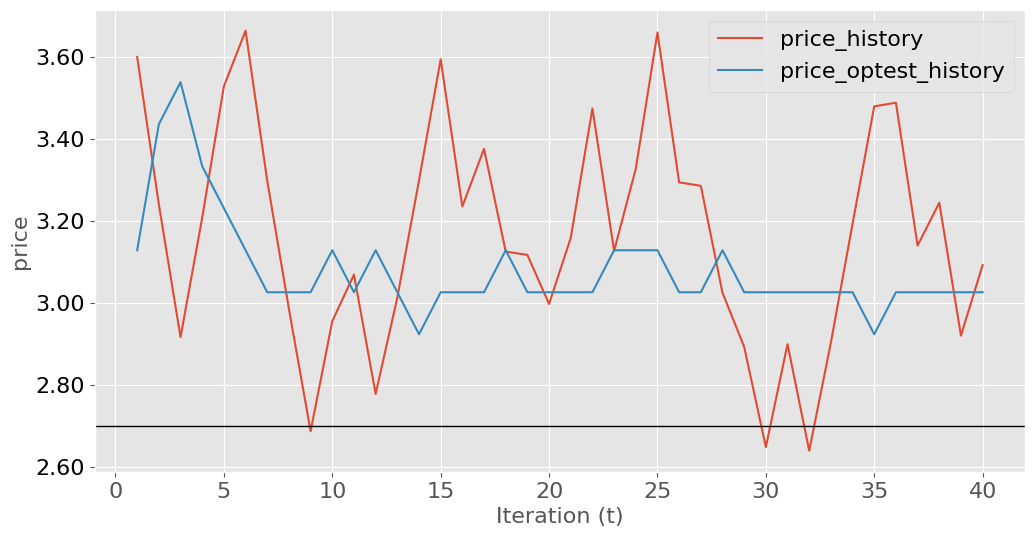

In [8]:
bp.lineplot(
    df_ts_summary, x ="n",
    y = ["price_history", "price_optest_history"], 
    y_axis_label='price',
    x_axis_label='Iteration (t)',
    h_line = p_opt,
    #y_lims = (2, 4.5),
    #x_lims = (1, 10),
    figsize=(12,6))

Convergence looks reasonably good
* early phase (t ~ 1 - 10) 
  * Fast learning, large parameter moves, price swings. Normal.
* middle phase  (t~ 10 - 25)
  * Parameters stabilize:
  * v settles around optimum, similarly a, sigma\_log, p* 
* late phase (t ~ 25 - 30) ...
  * TS wiggle is normal
  * continuted exploration 
  * price continutes woble, as does p_opt_ext, this is normal due to exploration
  * flat surface near optimum, p*  ... small parameter noise 
  * potentially price grid could be improved ... jumping between grid points 2.72, , 2.82, 2.63
  * no runaway bias this basically looks good
* Potential improvements
  * increase price grid ... not sure this will help too much already within 2 digits
  * potentially reduce local min max after burn in 


In dynamic pricing with constant-elasticity demand, the profit function is locally flat around the optimal price. As a result, Thompson Sampling does not converge to a single price but instead samples within a near-optimal price region, leading to persistent but harmless price oscillations.

Ferira, Lee & Simchi-Levi, 2018, “Analytics for an online retailer: Demand forecasting and price optimization”, Explicitly notes that noise + flat revenue causes persistent variability.

Agrawal & GOyal (2012), Explicitly notes that noise + flat revenue causes persistent variability. Formalizes that TS samples among actions with similar expected reward. Flat reward ⇒ persistent exploration

den Boer, 2015, “Dynamic pricing and learning: historical origins, current research, and new directions” , Surveys in Operations Research. Survey paper, Describes that optimal price regions are often intervals, not points, TS and Bayesian pricing naturally cycle within these regions

# Profit

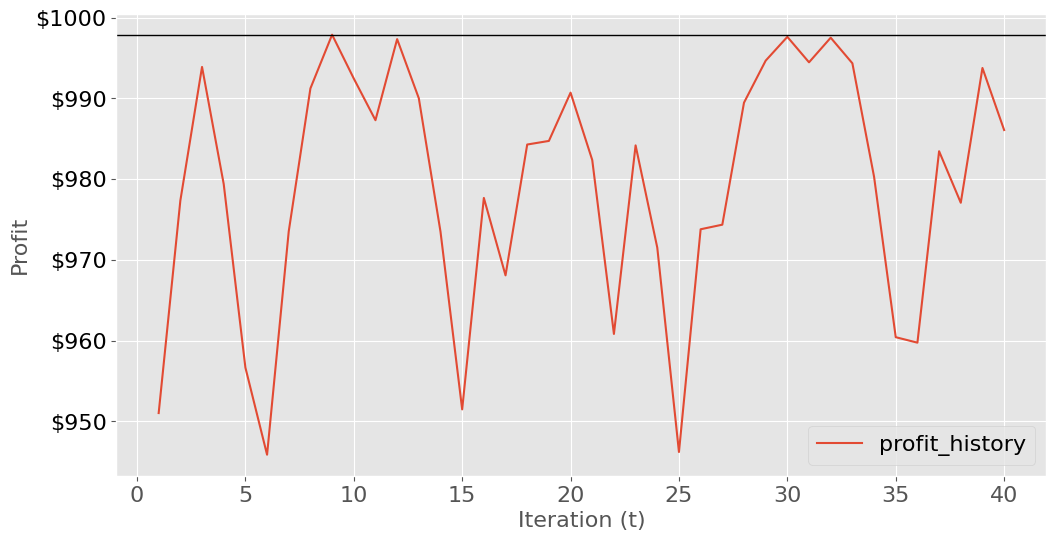

In [9]:
bp.lineplot(df_ts_summary, x="n",
    y = ["profit_history"],
    y_axis_label='Profit',
    x_axis_label='Iteration (t)',
    y_axis_format=".0f",
    y_currency="$",
    h_line = Profit_opt,
    figsize=(12,6)
)


# Tightening

In [11]:
# Tightening

import arviz as az
import numpy as np
import matplotlib.pyplot as plt

def plot_hdi_width_over_time(traces,  var_names=("a", "v", "sigma_log"), hdi_prob=0.94, figsize=(12,6)):
    steps = np.arange(1, len(traces) + 1)

    
    for var in var_names:
        widths = []
        plt.figure(figsize=figsize)
        for idata in traces:
            # returns [low, high] for scalar vars
            hdi = az.hdi(idata.posterior[var], hdi_prob=hdi_prob).to_array().values
            # hdi shape is usually (2,) after to_array; handle safely:
            low, high = float(np.min(hdi)), float(np.max(hdi))
            widths.append(high - low)

        plt.plot(steps, widths, marker="o", label=f"{var} HDI width", color='#013bff',  linewidth=1)

        plt.title(f"Posterior tightening over time (HDI {int(hdi_prob*100)}% width)")
        plt.xlabel("step t")
        plt.ylabel("interval width (smaller = tighter)")
        plt.legend()
        plt.show()


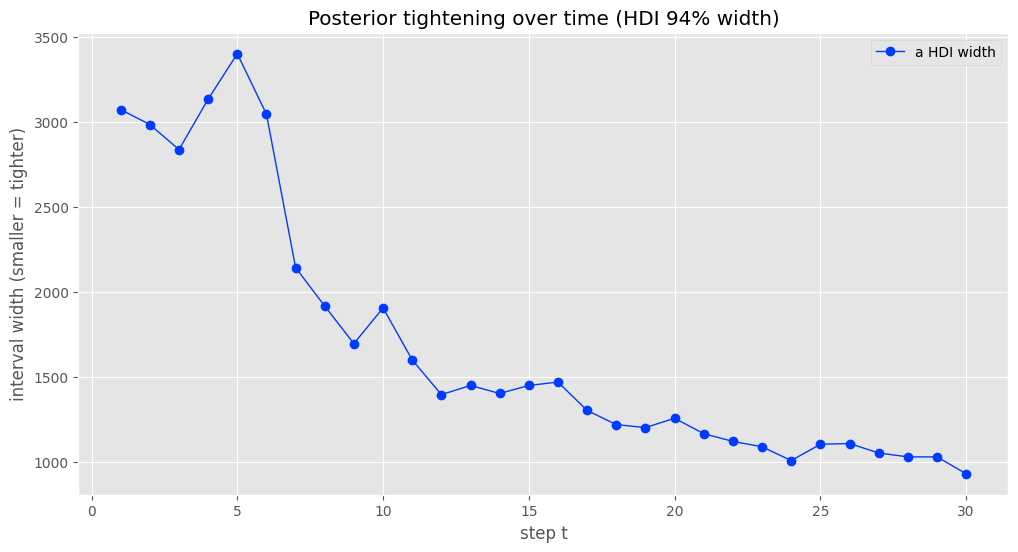

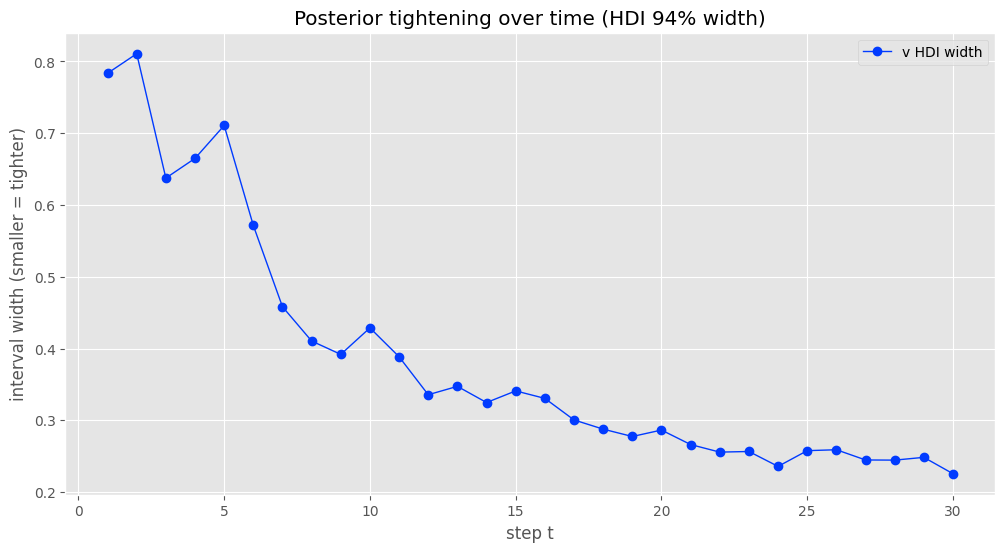

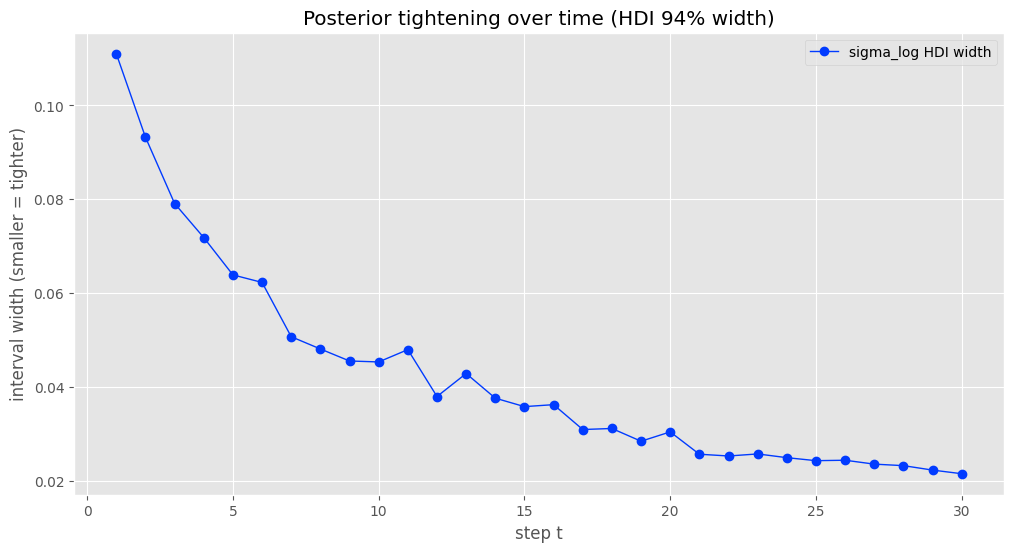

In [12]:
    
plot_hdi_width_over_time(_traces)
plt.show()

# Density plots over time

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib as mpl
from matplotlib.colors import Normalize

def _overlay_kde_series_colored(
    series,               # list of (t, samples_1d)
    title: str,
    xlabel: str,
    bw_method=None,
    quantile_clip=(0.002, 0.998),
    cmap_name="viridis",
):
    all_s = np.concatenate([s for _, s in series])
    lo, hi = np.quantile(all_s, list(quantile_clip))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = float(np.min(all_s)), float(np.max(all_s))
    pad = 0.02 * (hi - lo) if hi > lo else 1.0
    grid = np.linspace(lo - pad, hi + pad, 400)

    fig, ax = plt.subplots(figsize=(12, 7))

    ts = np.array([t for t, _ in series])
    norm = Normalize(vmin=ts.min(), vmax=ts.max())
    cmap = mpl.colormaps.get_cmap(cmap_name)

    for t, s in series:
        kde = gaussian_kde(s, bw_method=bw_method)
        ax.plot(
            grid,
            kde(grid),
            color=cmap(norm(t)),
            alpha=0.9,
        )

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label="step t")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    
    return fig,ax

In [14]:
import numpy as np

def _draws(idata, var_name: str) -> np.ndarray:
    """
    Flatten posterior draws for a scalar variable from an ArviZ InferenceData.
    """
    return np.asarray(idata.posterior[var_name]).reshape(-1)

In [15]:
def plot_demand_revenue_profit_densities_at_prices_colored(
    traces,
    prices_history,
    demand_revenue_profit:str,
    variable_cost: float,
    fixed_cost: float,
    bw_method=None,
    cmap_name="viridis",
    t_max = None, 
):
    if len(traces) != len(prices_history):
        raise ValueError(
            "len(traces) must equal len(prices_history): one trace + one price per step"
        )

    demand_series = []
    revenue_series = []
    profit_series  = []
    
    if t_max == None:
        t_max = len(traces)

    for t, (idata, p_t) in enumerate(zip(traces[0:t_max], prices_history[0:t_max]), start=1):
        a_s = _draws(idata, "a") # shaping parameter, a, parameter
        v_s = _draws(idata, "v") # elasticity, v, samples

        D_s  = a_s * (p_t ** (-v_s)) 
        R_s  = p_t * D_s
        Pi_s = (p_t - variable_cost) * D_s - fixed_cost

        demand_series.append((t, D_s))
        revenue_series.append((t, R_s))
        profit_series.append((t, Pi_s))

    if demand_revenue_profit not in {"demand", "revenue", "profit"}:
        raise ValueError(
            "demand_or_revenue_or_profit must be one of 'demand', 'revenue', or 'profit'"
        )
        
    if demand_revenue_profit  == "demand":
        fig,ax = _overlay_kde_series_colored(
            demand_series,
            title="Posterior density of demand at step-specific offered price p_t",
            xlabel="Demand D(p_t)",
            bw_method=bw_method,
            cmap_name=cmap_name,
        )

    if demand_revenue_profit  == "revenue":
        fig, ax = _overlay_kde_series_colored(
            revenue_series,
            title="Posterior density of revenue at step-specific offered price p_t",
            xlabel="Revenue R(p_t)",
            bw_method=bw_method,
            cmap_name=cmap_name,
        )

    if demand_revenue_profit  == "profit":
        fig, ax = _overlay_kde_series_colored(
            profit_series,
            title="Posterior density of profit at step-specific offered price p_t",
            xlabel="Profit (p_t)",
            bw_method=bw_method,
            cmap_name=cmap_name,
        )
        
    return fig, ax


In [16]:
t_max=None

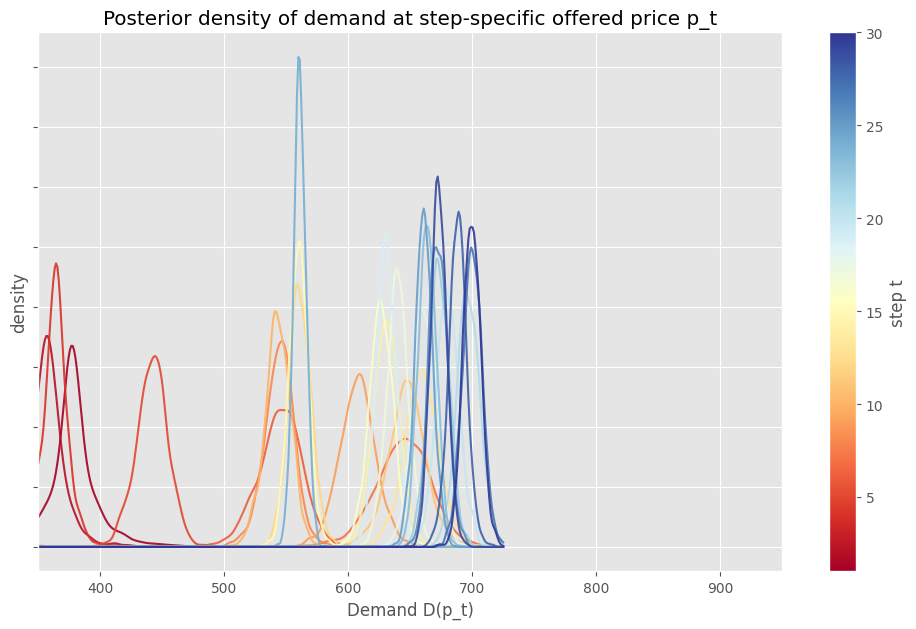

In [22]:
# demand
fig, ax = plot_demand_revenue_profit_densities_at_prices_colored(
    traces=_traces,
    prices_history=prices_history,
    demand_revenue_profit="demand",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    cmap_name="RdYlBu",   # "virdis", "plasma", "magma", "cividis",RdYlBu, "YlOrBr"
    t_max = t_max
)


ax.set_xlim(350, 950) 
ax.tick_params(axis='y', labelleft=False)

plt.show()


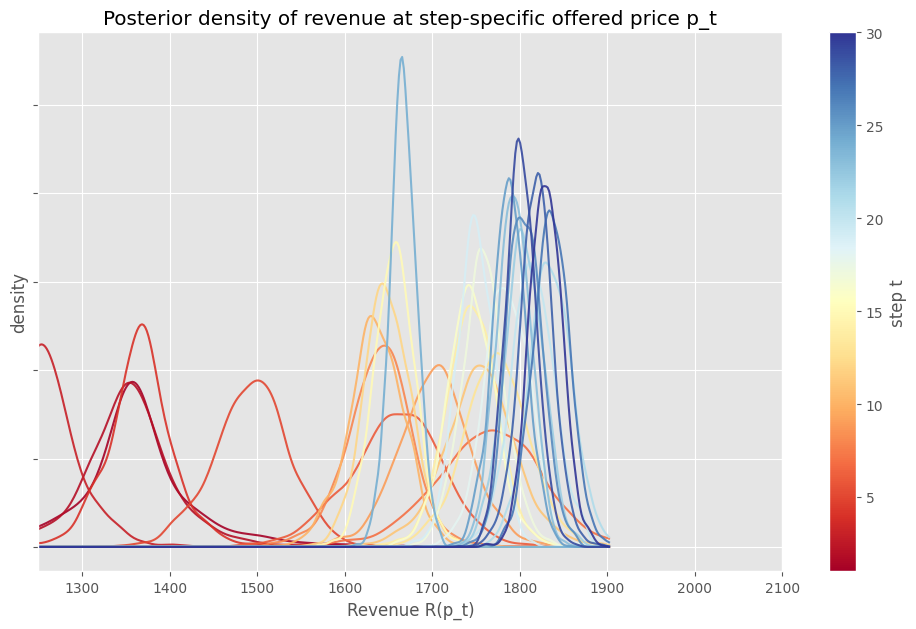

In [23]:
# revenue
fig,ax=plot_demand_revenue_profit_densities_at_prices_colored(
    traces=_traces,
    prices_history=prices_history,
    demand_revenue_profit="revenue",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    cmap_name="RdYlBu"   # "virdis", "plasma", "magma", "cividis"
)

ax.set_xlim(1250, 2100) 
ax.tick_params(axis='y', labelleft=False)
plt.show()

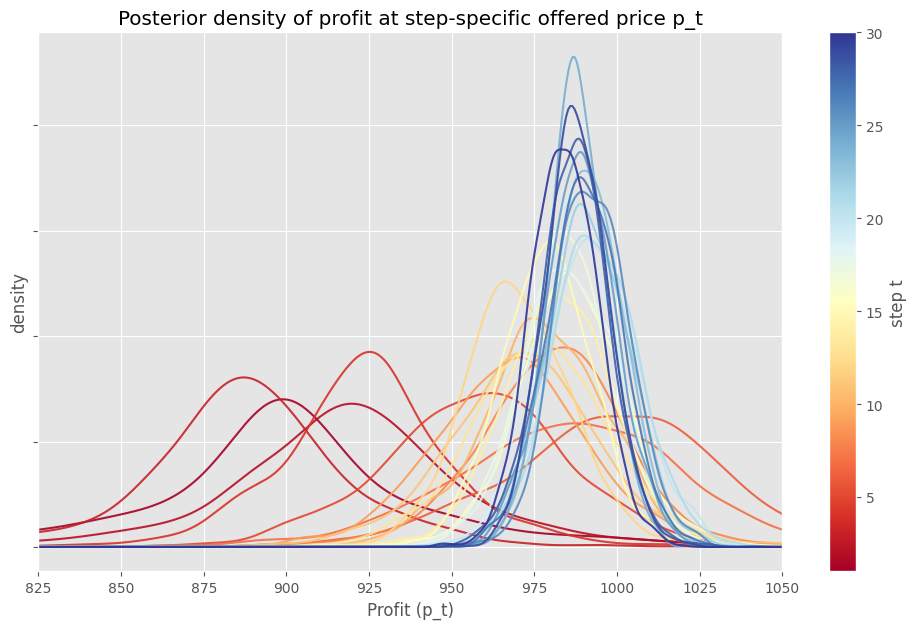

In [24]:
# profit
fig,ax=plot_demand_revenue_profit_densities_at_prices_colored(
    traces=_traces,
    prices_history=prices_history,
    demand_revenue_profit="profit",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    cmap_name="RdYlBu"   # "virdis", "plasma", "magma", "cividis"
)

ax.set_xlim(825, 1050) 
ax.tick_params(axis='y', labelleft=False)
plt.show()
plt.show()